# Atelier Préparation de Données Images

## Contexte

Une entreprise souhaite développer un système d'intelligence artificielle capable de reconnaître automatiquement le type de déchet présent sur une photographie afin d'améliorer le tri des déchets. Le modèle devra classer chaque image dans l'une des catégories suivantes :

- **cardboard** : cartons ondulés, cartons plats...
- **plastic** : bouteilles, emballages plastiques...
- **paper** : feuilles, journaux...
- **glass** : bouteilles et objets en verre...
- **metal** : canettes, boîtes métalliques...
- **trash** : emballages bonbons, tasses jetables...

Le problème est que les images collectées proviennent de plusieurs sources. Elles ne sont donc pas homogènes : dimensions différentes, formats différents, images RGB et grayscale, certaines images sont trop petites, certaines images sont corrompues, quelques images sont vides, images dupliquées, quelques images placées dans le mauvais dossier, classes déséquilibrées.

L'objectif de l'atelier est donc de construire un jeu de données images propre et homogène, prêt à être utilisé pour entraîner un modèle de Machine Learning ou de Deep Learning.

# Partie 1 – Exploration du dataset

In [1]:
# Partie 1 - Étape 1 : Imports nécessaires
import os
import numpy as np
import pandas as pd
from PIL import Image

In [2]:
# Partie 1 - Étape 2 : Fonction d'extraction des métadonnées d'une image
def extraire_metadonnees(chemin_image, classe):
    """
    Extrait les métadonnées d'une image : nom, classe, format, mode,
    largeur, hauteur, écart-type des pixels, nombre de canaux, taille.
    Retourne un dictionnaire, avec corrompue=True si l'image ne peut pas être lue.
    """
    nom_fichier = os.path.basename(chemin_image)
    taille_octets = os.path.getsize(chemin_image)

    try:
        with Image.open(chemin_image) as img:
            img.verify()  # vérifie l'intégrité du fichier sans le charger complètement

        # Réouverture nécessaire après verify() (qui "consomme" l'objet image)
        with Image.open(chemin_image) as img:
            largeur, hauteur = img.size
            format_img = img.format
            mode_img = img.mode

            img_array = np.array(img)
            ecart_type = img_array.std()
            nb_canaux = 1 if img_array.ndim == 2 else img_array.shape[2]

        return {
            'nom_fichier': nom_fichier,
            'classe': classe,
            'format': format_img,
            'mode': mode_img,
            'largeur': largeur,
            'hauteur': hauteur,
            'ecart_type_pixels': ecart_type,
            'nb_canaux': nb_canaux,
            'taille_octets': taille_octets,
            'corrompue': False
        }

    except Exception as e:
        return {
            'nom_fichier': nom_fichier,
            'classe': classe,
            'format': None,
            'mode': None,
            'largeur': None,
            'hauteur': None,
            'ecart_type_pixels': None,
            'nb_canaux': None,
            'taille_octets': taille_octets,
            'corrompue': True
        }

In [3]:
# Partie 1 - Étape 3 : Parcours de tout le dataset et construction du tableau récapitulatif
dossier_raw = "../data/raw"
classes = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

resultats = []

for classe in classes:
    dossier_classe = os.path.join(dossier_raw, classe)
    for nom_fichier in os.listdir(dossier_classe):
        chemin_complet = os.path.join(dossier_classe, nom_fichier)
        metadonnees = extraire_metadonnees(chemin_complet, classe)
        resultats.append(metadonnees)

df_images = pd.DataFrame(resultats)
df_images.shape

(1032, 10)

In [4]:
# Partie 1 - Étape 4 : Aperçu du résultat
print(df_images.head())
print("\nNombre d'images par classe :")
print(df_images['classe'].value_counts())
print("\nNombre d'images corrompues :", df_images['corrompue'].sum())

        nom_fichier     classe format mode  largeur  hauteur  \
0    cardboard1.jpg  cardboard   JPEG  RGB    512.0    384.0   
1   cardboard10.jpg  cardboard   JPEG  RGB    512.0    384.0   
2  cardboard100.jpg  cardboard   JPEG  RGB    512.0    384.0   
3  cardboard101.jpg  cardboard   JPEG  RGB    512.0    384.0   
4  cardboard102.jpg  cardboard   JPEG  RGB    512.0    384.0   

   ecart_type_pixels  nb_canaux  taille_octets  corrompue  
0          40.586504        3.0          17333      False  
1          42.577273        3.0          21683      False  
2          46.121684        3.0          14884      False  
3          72.264255        3.0          14289      False  
4          48.389753        3.0          18015      False  

Nombre d'images par classe :
classe
paper        252
plastic      224
glass        188
cardboard    169
metal        149
trash         50
Name: count, dtype: int64

Nombre d'images corrompues : 6


# Partie 2 – Détecter les images corrompues

In [5]:
# Partie 2 : Fonction de détection d'image corrompue
def est_corrompue(chemin_image):
    """
    Vérifie si une image est corrompue (fichier illisible, tronqué,
    ou n'étant pas une image valide). Retourne True si corrompue, False sinon.
    """
    try:
        with Image.open(chemin_image) as img:
            img.verify()
        return False
    except Exception:
        return True

In [6]:
# Partie 2 : Application de la fonction sur tout le dataset
images_corrompues = []

for classe in classes:
    dossier_classe = os.path.join(dossier_raw, classe)
    for nom_fichier in os.listdir(dossier_classe):
        chemin_complet = os.path.join(dossier_classe, nom_fichier)
        if est_corrompue(chemin_complet):
            images_corrompues.append({'nom_fichier': nom_fichier, 'classe': classe})

df_corrompues = pd.DataFrame(images_corrompues)
print("Nombre d'images corrompues détectées :", len(df_corrompues))
df_corrompues

Nombre d'images corrompues détectées : 6


,nom_fichier,classe
0,cardboard83.jpg,cardboard
1,glass74.jpg,glass
2,metal48.jpg,metal
3,paper213.jpg,paper
4,plastic13.jpg,plastic
5,trash3.jpg,trash


# Partie 3 – Détecter les images vides

In [7]:
# Partie 3 : Fonction de détection d'image vide
def est_vide(chemin_image, seuil_ecart_type=5):
    """
    Vérifie si une image est "vide" : entièrement noire, entièrement blanche,
    ou avec très peu de variation de pixels (écart-type sous le seuil).
    Retourne True si l'image est considérée comme vide, False sinon.
    Retourne None si l'image est corrompue (ne peut pas être analysée).
    """
    if est_corrompue(chemin_image):
        return None

    with Image.open(chemin_image) as img:
        img_array = np.array(img)

    ecart_type = img_array.std()
    moyenne = img_array.mean()

    # Image entièrement noire (moyenne proche de 0) ou blanche (moyenne proche de 255)
    entierement_noire = moyenne < 5
    entierement_blanche = moyenne > 250
    peu_de_variation = ecart_type < seuil_ecart_type

    return entierement_noire or entierement_blanche or peu_de_variation

In [8]:
# Partie 3 : Application de la fonction sur tout le dataset
images_vides = []

for classe in classes:
    dossier_classe = os.path.join(dossier_raw, classe)
    for nom_fichier in os.listdir(dossier_classe):
        chemin_complet = os.path.join(dossier_classe, nom_fichier)
        resultat = est_vide(chemin_complet)
        if resultat:
            images_vides.append({'nom_fichier': nom_fichier, 'classe': classe})

df_vides = pd.DataFrame(images_vides)
print("Nombre d'images vides détectées :", len(df_vides))
df_vides

Nombre d'images vides détectées : 2


,nom_fichier,classe
0,image-blanche-512x384.jpg,cardboard
1,image-blanche-512x384.jpg,metal


# Partie 4 – Détecter les différences de résolution

In [9]:
# Partie 4 - Question 1 : Statistiques de résolution
# On exclut les images corrompues, qui n'ont pas de largeur/hauteur valides
df_valides = df_images[df_images['corrompue'] == False].copy()

print("Résolution minimale (largeur) :", df_valides['largeur'].min())
print("Résolution minimale (hauteur) :", df_valides['hauteur'].min())
print("Résolution maximale (largeur) :", df_valides['largeur'].max())
print("Résolution maximale (hauteur) :", df_valides['hauteur'].max())

print("\nRésolutions les plus fréquentes :")
resolutions = df_valides.groupby(['largeur', 'hauteur']).size().sort_values(ascending=False)
print(resolutions.head(10))

Résolution minimale (largeur) : 32.0
Résolution minimale (hauteur) : 32.0
Résolution maximale (largeur) : 512.0
Résolution maximale (hauteur) : 384.0

Résolutions les plus fréquentes :
largeur  hauteur
512.0    384.0      1013
32.0     32.0          5
40.0     40.0          4
48.0     32.0          4
dtype: int64


In [11]:
# Partie 4 - Question 2 : Images ne respectant pas la contrainte minimale de 64x64
images_trop_petites = df_valides[(df_valides['largeur'] < 64) | (df_valides['hauteur'] < 64)]

print("Nombre d'images trop petites :", len(images_trop_petites))
images_trop_petites[['nom_fichier', 'classe', 'largeur', 'hauteur']]

Nombre d'images trop petites : 13


,nom_fichier,classe,largeur,hauteur
20,cardboard117.jpg,cardboard,48.0,32.0
77,cardboard22.jpg,cardboard,32.0,32.0
133,cardboard70.jpg,cardboard,40.0,40.0
171,glass100.jpg,glass,40.0,40.0
229,glass15.jpg,glass,48.0,32.0
268,glass21.jpg,glass,32.0,32.0
270,glass23.jpg,glass,32.0,32.0
383,metal121.jpg,metal,48.0,32.0
413,metal2.jpg,metal,32.0,32.0
421,metal26.jpg,metal,40.0,40.0


# Partie 5 – Détecter les différents canaux

In [12]:
# Partie 5 : Nombre d'images selon leur nombre de canaux
df_valides['nb_canaux'].value_counts()

nb_canaux
3.0    1006
4.0      18
1.0       2
Name: count, dtype: int64

# Partie 6 – Détecter les doublons

In [14]:
# Partie 6 : Fonction de calcul du hash d'une image
import hashlib

def calculer_hash(chemin_image):
    """
    Calcule un hash MD5 du contenu binaire d'une image.
    Retourne None si l'image est corrompue.
    """
    if est_corrompue(chemin_image):
        return None

    with open(chemin_image, 'rb') as f:
        contenu = f.read()
    return hashlib.md5(contenu).hexdigest()

In [15]:
# Partie 6 : Application - détection des doublons sur tout le dataset
hashes = []

for classe in classes:
    dossier_classe = os.path.join(dossier_raw, classe)
    for nom_fichier in os.listdir(dossier_classe):
        chemin_complet = os.path.join(dossier_classe, nom_fichier)
        h = calculer_hash(chemin_complet)
        hashes.append({'nom_fichier': nom_fichier, 'classe': classe, 'hash': h})

df_hashes = pd.DataFrame(hashes)

# Identifier les doublons : hash présent plus d'une fois (en excluant les None des corrompues)
df_hashes_valides = df_hashes[df_hashes['hash'].notna()]
doublons = df_hashes_valides[df_hashes_valides.duplicated(subset='hash', keep=False)].sort_values('hash')

print("Nombre d'images dupliquées (occurrences totales) :", len(doublons))
doublons

Nombre d'images dupliquées (occurrences totales) : 30


,nom_fichier,classe,hash
732,paper77ty.jpg,paper,098ca18d235424eec30cc10f743ff155
731,paper77.jpg,paper,098ca18d235424eec30cc10f743ff155
388,metal125po.jpg,metal,0b0dafc63da482605bac609d6e327a0a
387,metal125.jpg,metal,0b0dafc63da482605bac609d6e327a0a
838,plastic171.jpg,plastic,0fde5dfaea544255c189f9a262854200
839,plastic171az.jpg,plastic,0fde5dfaea544255c189f9a262854200
355,image-noire-512x384.png,glass,213b77974c84c6db40cc487743d92981
358,image-noire-512x384.png,metal,213b77974c84c6db40cc487743d92981
167,image-blanche-512x384.jpg,cardboard,2624c04611d93c7ef187d7fd0ab41216
357,image-blanche-512x384.jpg,metal,2624c04611d93c7ef187d7fd0ab41216


In [17]:
# Partie 6 : Synthèse des doublons
nb_groupes = doublons['hash'].nunique()
nb_images_en_trop = len(doublons) - nb_groupes

print("Nombre de groupes de doublons :", nb_groupes)
print("Nombre d'images 'en trop' (copies à retirer) :", nb_images_en_trop)

# Doublons inter-classes (signal pour la Partie 7 - images mal classées)
doublons_inter_classes = doublons.groupby('hash')['classe'].nunique()
hashes_inter_classes = doublons_inter_classes[doublons_inter_classes > 1].index
print("\nDoublons présents dans des classes différentes :")
doublons[doublons['hash'].isin(hashes_inter_classes)][['nom_fichier', 'classe', 'hash']]

Nombre de groupes de doublons : 15
Nombre d'images 'en trop' (copies à retirer) : 15

Doublons présents dans des classes différentes :


,nom_fichier,classe,hash
355,image-noire-512x384.png,glass,213b77974c84c6db40cc487743d92981
358,image-noire-512x384.png,metal,213b77974c84c6db40cc487743d92981
167,image-blanche-512x384.jpg,cardboard,2624c04611d93c7ef187d7fd0ab41216
357,image-blanche-512x384.jpg,metal,2624c04611d93c7ef187d7fd0ab41216
496,metal91.jpg,metal,70df08c3ce6d55e25df4edbbe45e5fe3
188,glass115.jpg,glass,70df08c3ce6d55e25df4edbbe45e5fe3
356,image-violet-512x384.gif,glass,a17586b081d1d45b7f70d644f8faf0a7
168,image-violet-512x384.gif,cardboard,a17586b081d1d45b7f70d644f8faf0a7
817,plastic152.jpg,plastic,a2236bc6f8eae80bf7d6c5f259df8760
258,glass176.jpg,glass,a2236bc6f8eae80bf7d6c5f259df8760


# Partie 7 – Détecter les images mal classées

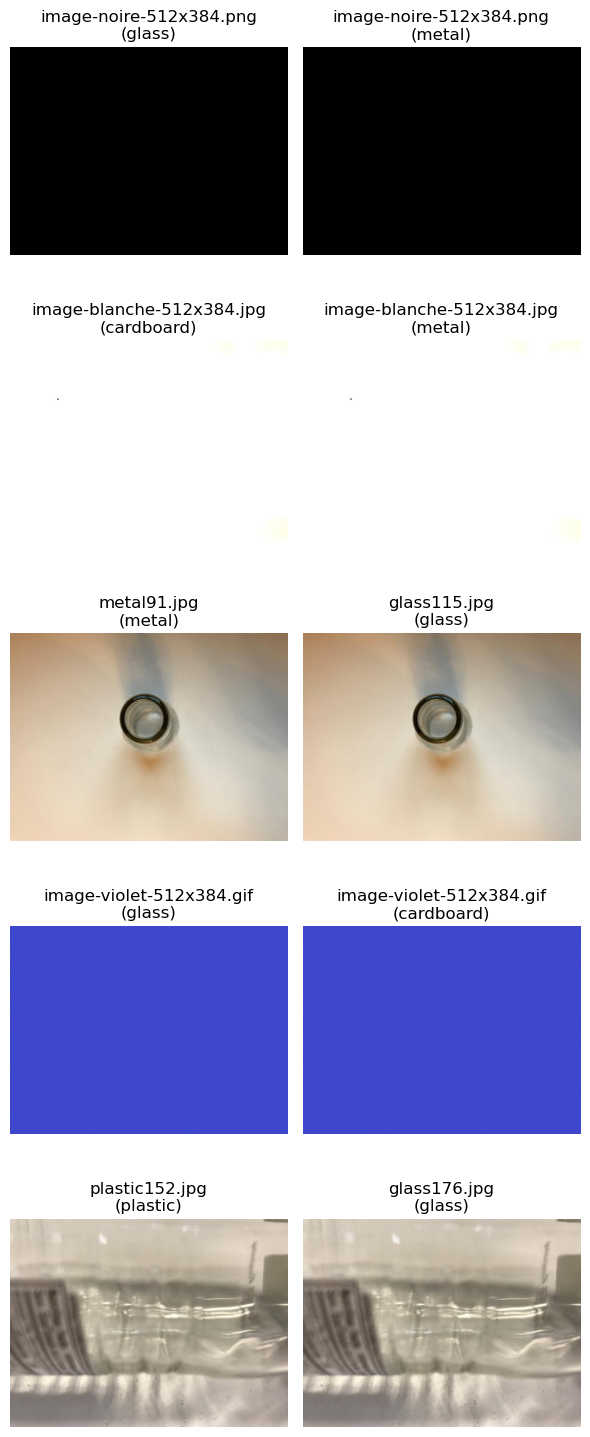

In [18]:
# Partie 7 - Étape 1 : Affichage des doublons inter-classes pour contrôle visuel
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(hashes_inter_classes), 2, figsize=(6, 3 * len(hashes_inter_classes)))

for i, h in enumerate(hashes_inter_classes):
    lignes = doublons[doublons['hash'] == h]
    for j, (_, ligne) in enumerate(lignes.iterrows()):
        chemin = os.path.join(dossier_raw, ligne['classe'], ligne['nom_fichier'])
        img = Image.open(chemin)
        axes[i, j].imshow(img)
        axes[i, j].set_title(f"{ligne['nom_fichier']}\n({ligne['classe']})")
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

**Partie 7 - Étape 1 : Résultat du contrôle visuel des doublons inter-classes**

- `image-noire-512x384.png`, `image-blanche-512x384.jpg`, `image-violet-512x384.gif` : images de test synthétiques (déjà identifiées comme "vides" en Partie 3), ne représentant aucun vrai déchet — à exclure du dataset plutôt qu'à reclasser.
- `glass115.jpg` : objet métallique visible sur l'image → mal classée, devrait être en `metal` (comme sa copie `metal91.jpg`).
- `plastic152.jpg` / `glass176.jpg` : image ambiguë (bouteille transparente) — classification incertaine, à signaler pour vérification manuelle plutôt que de trancher automatiquement.

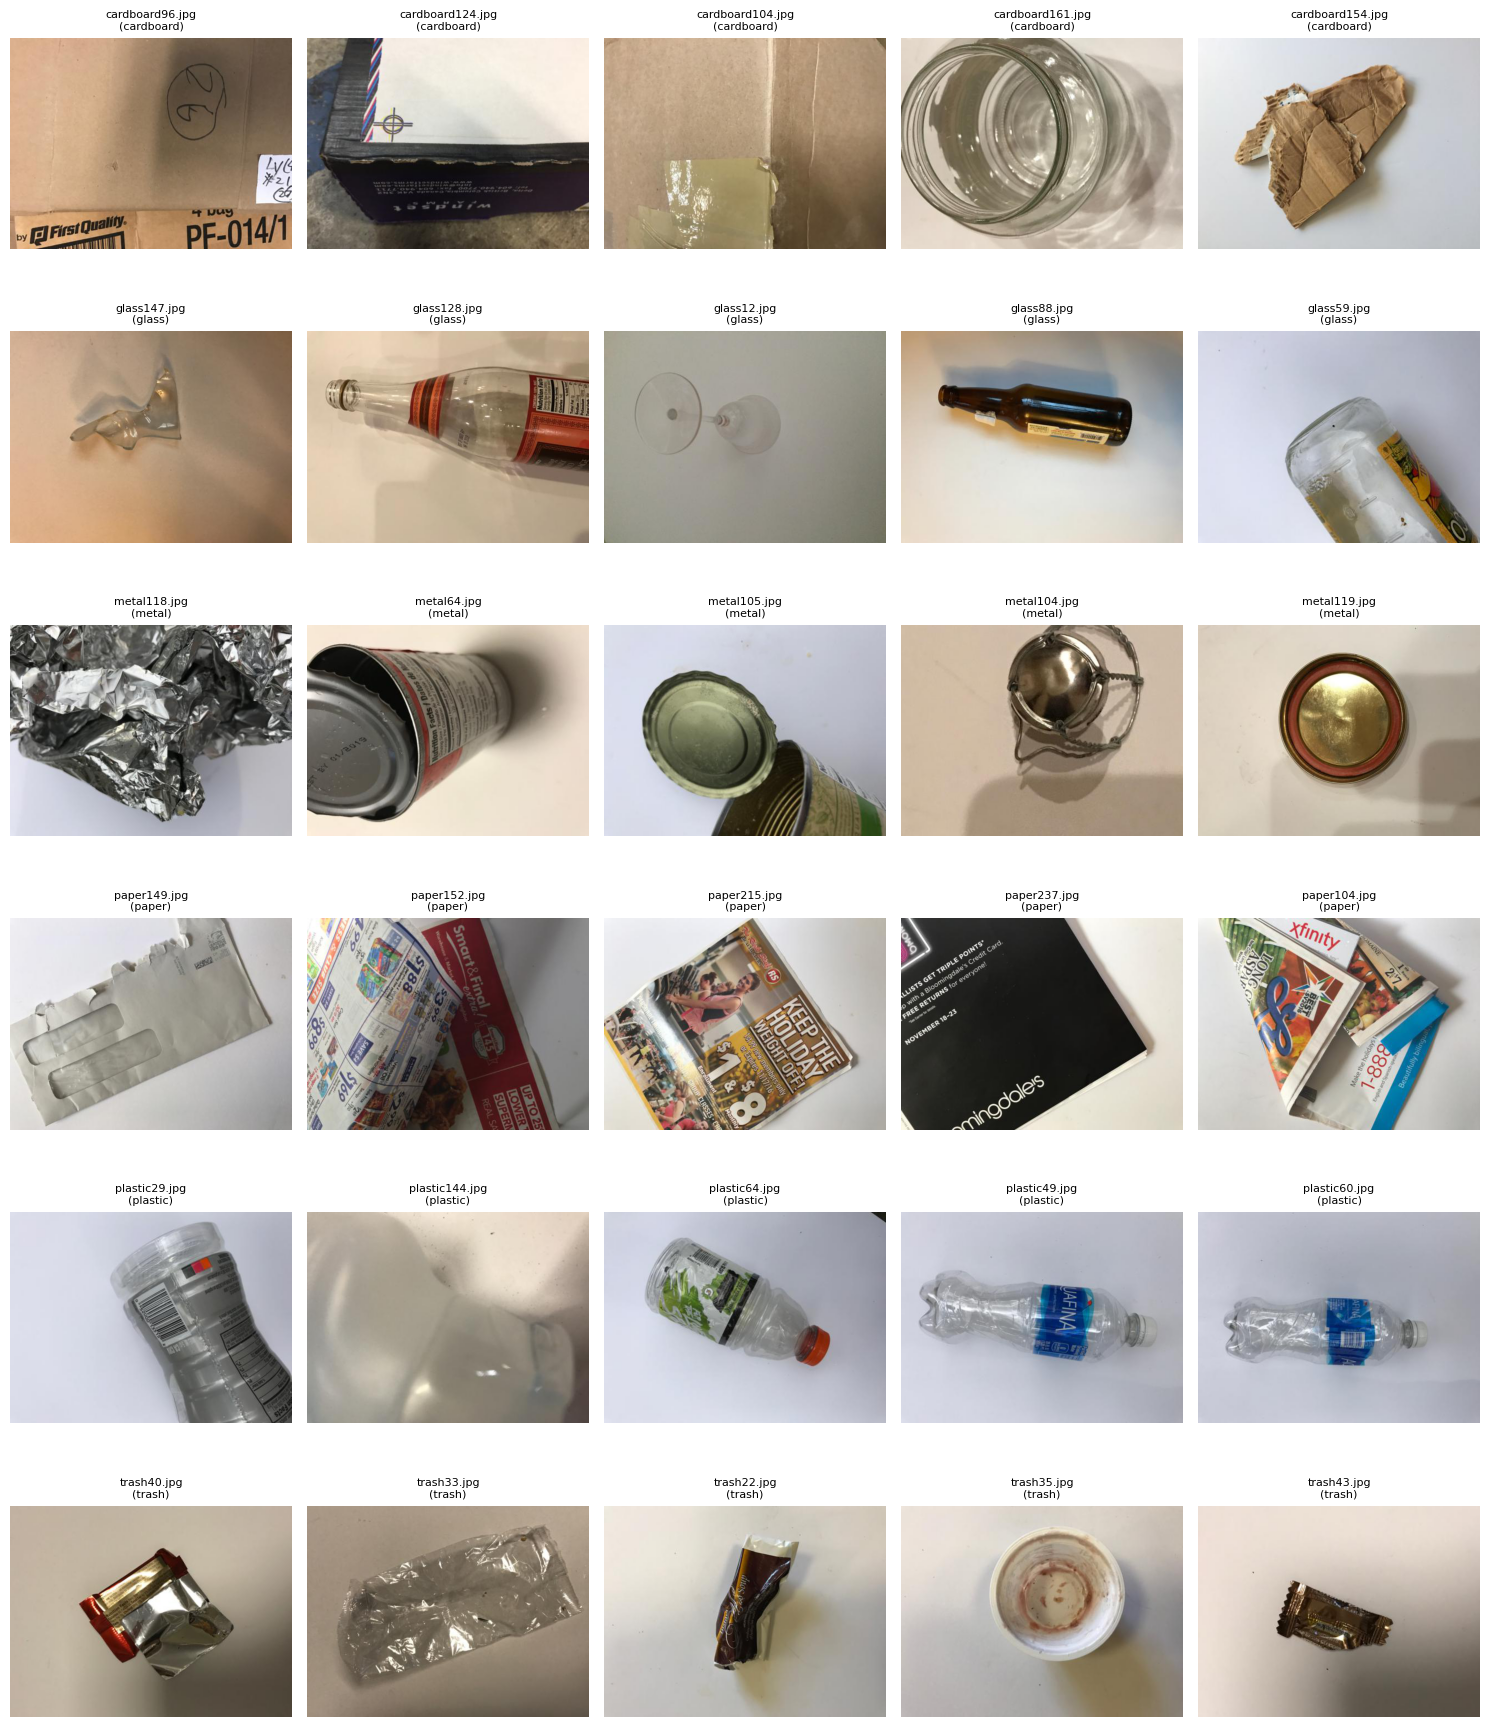

In [19]:
# Partie 7 - Étape 2 : Échantillon aléatoire par classe pour contrôle visuel
import random

random.seed(42)
fig, axes = plt.subplots(len(classes), 5, figsize=(15, 3 * len(classes)))

for i, classe in enumerate(classes):
    dossier_classe = os.path.join(dossier_raw, classe)
    fichiers = os.listdir(dossier_classe)
    echantillon = random.sample(fichiers, min(5, len(fichiers)))

    for j, nom_fichier in enumerate(echantillon):
        chemin = os.path.join(dossier_classe, nom_fichier)
        try:
            img = Image.open(chemin)
            axes[i, j].imshow(img)
        except Exception:
            axes[i, j].text(0.5, 0.5, 'Corrompue', ha='center')
        axes[i, j].set_title(f"{nom_fichier}\n({classe})", fontsize=8)
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

**Partie 7 - Étape 2 : Résultat du contrôle visuel par échantillon aléatoire**

Sur l'échantillon de 30 images (5 par classe), une image suspecte a été identifiée :
- `cardboard104.jpg` : représente un pot en verre, potentiellement mal classée (devrait être en `glass`).

Le reste de l'échantillon est cohérent avec sa classe d'appartenance.

**Synthèse des images mal classées identifiées (Étapes 1 et 2) :**
- `glass115.jpg` → probablement `metal` (doublon de `metal91.jpg`)h
- `cardboard104.jpg` → probablement `glass`
- `plastic152.jpg` / `glass176.jpg` → ambiguë, à vérifier manuellement

# Partie 8 – Analyser le déséquilibre des classes

In [23]:
# Partie 8 : Nombre d'images par classe
df_images['classe'].value_counts()


classe
paper        252
plastic      224
glass        188
cardboard    169
metal        149
trash         50
Name: count, dtype: int64

In [24]:
print("\nProportions par classe (%) :")
(df_images['classe'].value_counts(normalize=True) * 100).round(2)


Proportions par classe (%) :


classe
paper        24.42
plastic      21.71
glass        18.22
cardboard    16.38
metal        14.44
trash         4.84
Name: proportion, dtype: float64

**Partie 8 : Analyse du déséquilibre des classes**

Répartition très inégale entre les 6 classes :
- `paper` : 252 images (24.42%) — classe majoritaire
- `plastic` : 224 images (21.71%)
- `glass` : 188 images (18.22%)
- `cardboard` : 169 images (16.38%)
- `metal` : 149 images (14.44%)
- `trash` : 50 images (4.84%) — classe très minoritaire, ratio d'environ 1:5 par rapport à `paper`

Ce déséquilibre justifie l'application d'une data augmentation ciblée sur la classe minoritaire (`trash`), comme prévu en Partie 13, afin d'éviter qu'un futur modèle ne néglige cette classe lors de l'entraînement.

In [25]:
# Construction du fichier d'audit consolidé
audit = {
    "total_images": len(df_images),
    "images_corrompues": df_images['corrompue'].sum(),
    "images_quasi_vides": len(df_vides),
    "images_trop_petites": len(images_trop_petites),
    "doublons": nb_images_en_trop,
    "images_grayscale": (df_valides['nb_canaux'] == 1).sum(),
    "images_rgba": (df_valides['nb_canaux'] == 4).sum(),
    "images_mal_classees": 3  # glass115, cardboard104, glass176/plastic152 (cas ambigu inclus)
}

df_audit = pd.DataFrame([audit])
df_audit

,total_images,images_corrompues,images_quasi_vides,images_trop_petites,doublons,images_grayscale,images_rgba,images_mal_classees
0,1032,6,2,13,15,2,18,3


In [26]:
# Export du fichier d'audit
df_audit.to_csv("../reports/audit_images.csv", index=False)

# Partie 9 – Redimensionnement

In [27]:
# Partie 9 - Étape 1 : Consolidation des exclusions et reclassements

# Fichiers corrompus (nom_fichier, classe)
exclusions_corrompues = set(zip(df_images[df_images['corrompue']]['nom_fichier'],
                                  df_images[df_images['corrompue']]['classe']))

# Fichiers vides/synthétiques identifiés en Partie 3 + Partie 7 (image-violet)
noms_vides_synthetiques = ['image-blanche-512x384.jpg', 'image-noire-512x384.png', 'image-violet-512x384.gif']
exclusions_vides = set(zip(df_images[df_images['nom_fichier'].isin(noms_vides_synthetiques)]['nom_fichier'],
                             df_images[df_images['nom_fichier'].isin(noms_vides_synthetiques)]['classe']))

# Doublons en trop : on garde la première occurrence de chaque hash, on exclut les suivantes
doublons_tries = df_hashes_valides[df_hashes_valides.duplicated(subset='hash', keep=False)].sort_values('hash')
doublons_a_exclure = doublons_tries[doublons_tries.duplicated(subset='hash', keep='first')]
exclusions_doublons = set(zip(doublons_a_exclure['nom_fichier'], doublons_a_exclure['classe']))

# Union de toutes les exclusions
toutes_exclusions = exclusions_corrompues | exclusions_vides | exclusions_doublons
print("Nombre total d'exclusions (dédupliquées) :", len(toutes_exclusions))

# Reclassements : (nom_fichier, ancienne_classe) -> nouvelle_classe
reclassements = {
    ('glass115.jpg', 'glass'): 'metal',
    ('cardboard104.jpg', 'cardboard'): 'glass'
}
print("Nombre de reclassements :", len(reclassements))

Nombre total d'exclusions (dédupliquées) : 24
Nombre de reclassements : 2


In [33]:
# Partie 9 - Étape 2  : redimensionnement avec padding
def redimensionner_avec_padding(img, taille_cible=224):
    """
    Redimensionne une image PIL vers un carré de taille_cible x taille_cible,
    en conservant le ratio largeur/hauteur et le mode d'origine de l'image,
    avec ajout de padding pour combler l'espace restant.
    """
    largeur, hauteur = img.size
    ratio = min(taille_cible / largeur, taille_cible / hauteur)
    nouvelle_largeur = int(largeur * ratio)
    nouvelle_hauteur = int(hauteur * ratio)

    img_redimensionnee = img.resize((nouvelle_largeur, nouvelle_hauteur), Image.LANCZOS)

    # Couleur de padding adaptée au mode de l'image (0 = noir, quel que soit le nombre de canaux)
    if img.mode == 'RGBA':
        couleur_padding = (0, 0, 0, 0)
    elif img.mode in ('L', 'P'):
        couleur_padding = 0
    else:
        couleur_padding = (0, 0, 0)

    img_finale = Image.new(img.mode, (taille_cible, taille_cible), couleur_padding)
    offset_x = (taille_cible - nouvelle_largeur) // 2
    offset_y = (taille_cible - nouvelle_hauteur) // 2
    img_finale.paste(img_redimensionnee, (offset_x, offset_y))

    return img_finale

In [34]:
# Partie 9 - Étape 3 : création des dossiers + redimensionnement (mode préservé)
for classe in classes:
    os.makedirs(os.path.join(dossier_cleaned, classe), exist_ok=True)

nb_traitees = 0
nb_exclues = 0
nb_reclassees = 0

for classe in classes:
    dossier_classe_raw = os.path.join(dossier_raw, classe)
    for nom_fichier in os.listdir(dossier_classe_raw):

        if (nom_fichier, classe) in toutes_exclusions:
            nb_exclues += 1
            continue

        chemin_source = os.path.join(dossier_classe_raw, nom_fichier)
        classe_destination = reclassements.get((nom_fichier, classe), classe)
        if classe_destination != classe:
            nb_reclassees += 1

        dossier_destination = os.path.join(dossier_cleaned, classe_destination)
        chemin_sortie = os.path.join(dossier_destination, nom_fichier)

        try:
            with Image.open(chemin_source) as img:
                img_finale = redimensionner_avec_padding(img)
                img_finale.save(chemin_sortie)
                nb_traitees += 1
        except Exception as e:
            print(f"Erreur sur {nom_fichier} : {e}")

print("Images traitées et enregistrées :", nb_traitees)
print("Images exclues :", nb_exclues)
print("Images reclassées :", nb_reclassees)

Erreur sur metal13z.jpg : cannot write mode RGBA as JPEG
Erreur sur metal62rt.jpg : cannot write mode RGBA as JPEG
Images traitées et enregistrées : 1006
Images exclues : 24
Images reclassées : 1


**Note Partie 9 : Images non traitées à ce stade**

2 images en mode RGBA (`metal13z.jpg`, `metal62rt.jpg`) n'ont pas pu être sauvegardées en `.jpg` à cette étape, le format JPEG ne supportant pas la transparence. Elles seront intégrées à `cleaned/` après leur conversion en RGB, réalisée à la Partie 10 (Uniformisation des canaux).

**Bilan Partie 9 :** 1006 images redimensionnées et enregistrées dans `cleaned/`, 24 exclues (corrompues, vides/synthétiques, doublons), 1 reclassée (`cardboard104.jpg` → `glass`).

# Partie 10 – Uniformisation des canaux

In [35]:
# Partie 10 : Uniformisation des canaux (conversion en RGB)
nb_converties = 0
nb_deja_rgb = 0

# 1. Conversion des images déjà présentes dans cleaned/ (RGBA, P, etc.)
for classe in classes:
    dossier_classe_cleaned = os.path.join(dossier_cleaned, classe)
    for nom_fichier in os.listdir(dossier_classe_cleaned):
        chemin = os.path.join(dossier_classe_cleaned, nom_fichier)
        with Image.open(chemin) as img:
            if img.mode != 'RGB':
                img_rgb = img.convert('RGB')
                img_rgb.save(chemin)
                nb_converties += 1
            else:
                nb_deja_rgb += 1

# 2. Traitement des 2 images RGBA restées en attente (Partie 9)
images_en_attente = [
    ('metal13z.jpg', 'metal'),
    ('metal62rt.jpg', 'metal')
]

for nom_fichier, classe in images_en_attente:
    chemin_source = os.path.join(dossier_raw, classe, nom_fichier)
    with Image.open(chemin_source) as img:
        img_rgb = img.convert('RGB')
        img_finale = redimensionner_avec_padding(img_rgb)
        img_finale.save(os.path.join(dossier_cleaned, classe, nom_fichier))
        nb_converties += 1

print("Images converties en RGB :", nb_converties)
print("Images déjà en RGB :", nb_deja_rgb)
print("Total images dans cleaned :", sum(len(os.listdir(os.path.join(dossier_cleaned, c))) for c in classes))

Images converties en RGB : 16
Images déjà en RGB : 992
Total images dans cleaned : 1008


# Partie 11 – Mise à l'échelle des pixels

In [36]:
# Partie 11 : Normalisation des pixels de toutes les images (en mémoire)
images_normalisees = []
labels = []

for classe in classes:
    dossier_classe_cleaned = os.path.join(dossier_cleaned, classe)
    for nom_fichier in os.listdir(dossier_classe_cleaned):
        chemin = os.path.join(dossier_classe_cleaned, nom_fichier)
        with Image.open(chemin) as img:
            img_array = np.array(img) / 255.0
        images_normalisees.append(img_array)
        labels.append(classe)

images_normalisees = np.array(images_normalisees)
labels = np.array(labels)

print("Shape du tableau d'images normalisées :", images_normalisees.shape)
print("Min :", images_normalisees.min(), "/ Max :", images_normalisees.max())
print("Nombre de labels :", len(labels))

Shape du tableau d'images normalisées : (1008, 224, 224, 3)
Min : 0.0 / Max : 1.0
Nombre de labels : 1008


# Partie 12 – Découpage Train/Validation/Test

In [37]:
# Partie 12 : Découpage Train/Validation/Test (70/15/15, stratifié)
from sklearn.model_selection import train_test_split

# Étape 1 : Train (70%) vs Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    images_normalisees, labels,
    test_size=0.3,
    random_state=42,
    stratify=labels
)

# Étape 2 : Validation (15%) vs Test (15%) à partir du Temp (30%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print("Train :", X_train.shape, y_train.shape)
print("Validation :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

Train : (705, 224, 224, 3) (705,)
Validation : (151, 224, 224, 3) (151,)
Test : (152, 224, 224, 3) (152,)


In [38]:
# Vérification de la stratification
print("Proportions Train :")
print(pd.Series(y_train).value_counts(normalize=True).round(3) * 100)

print("\nProportions Validation :")
print(pd.Series(y_val).value_counts(normalize=True).round(3) * 100)

print("\nProportions Test :")
print(pd.Series(y_test).value_counts(normalize=True).round(3) * 100)

Proportions Train :
paper        24.7
plastic      21.7
glass        18.3
cardboard    16.3
metal        14.2
trash         4.8
Name: proportion, dtype: float64

Proportions Validation :
paper        24.5
plastic      21.9
glass        17.9
cardboard    16.6
metal        13.9
trash         5.3
Name: proportion, dtype: float64

Proportions Test :
paper        24.3
plastic      21.7
glass        18.4
cardboard    16.4
metal        14.5
trash         4.6
Name: proportion, dtype: float64


# Partie 13 – Data Augmentation

In [42]:
# Partie 13 - Question 1 : Data augmentation sur la classe minoritaire (trash)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Isoler les images de la classe trash dans le train
indices_trash = np.where(y_train == 'trash')[0]
X_trash = X_train[indices_trash]

print("Nombre d'images trash dans le train avant augmentation :", len(X_trash))

# Générateur de data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,          # rotation légère
    horizontal_flip=True,       # retournement horizontal
    zoom_range=0.1,              # zoom
    width_shift_range=0.1,       # translation horizontale
    height_shift_range=0.1,      # translation verticale
    brightness_range=[0.8, 1.2], # variation de luminosité
    channel_shift_range=20.0     # légère variation de couleur
)

# Génération de nouvelles images augmentées (calibré pour rapprocher trash des autres classes minoritaires)
nb_images_a_generer = 66
images_augmentees = []

gen = datagen.flow(X_trash, batch_size=1)
for _ in range(nb_images_a_generer):
    img_augmentee = next(gen)[0]
    images_augmentees.append(img_augmentee)

images_augmentees = np.array(images_augmentees)
print("Nombre d'images augmentées générées :", len(images_augmentees))

# Intégration au train
labels_augmentes = np.array(['trash'] * len(images_augmentees))
X_train_augmente = np.concatenate([X_train, images_augmentees])
y_train_augmente = np.concatenate([y_train, labels_augmentes])

print("\nShape X_train avant augmentation :", X_train.shape)
print("Shape X_train après augmentation :", X_train_augmente.shape)

print("\nNouvelle proportion de trash dans le train :")
print(pd.Series(y_train_augmente).value_counts(normalize=True).round(3) * 100)

Nombre d'images trash dans le train avant augmentation : 34
Nombre d'images augmentées générées : 66

Shape X_train avant augmentation : (705, 224, 224, 3)
Shape X_train après augmentation : (771, 224, 224, 3)

Nouvelle proportion de trash dans le train :
paper        22.6
plastic      19.8
glass        16.7
cardboard    14.9
metal        13.0
trash        13.0
Name: proportion, dtype: float64


**Question 2 : Pourquoi éviter la data augmentation avant le découpage train/val/test ?**

Si on applique la data augmentation **avant** de découper le dataset en train/validation/test, une image originale et ses versions augmentées (rotations, zooms, flips légers de la même image) risquent de se retrouver **séparées** entre le train et le test (ou la validation).

Cela crée une **fuite de données** : le modèle "voit" indirectement, pendant l'entraînement, des variantes très proches d'une image qu'il est censé prédire ensuite comme "nouvelle" dans le test. Concrètement, une image et sa version tournée de 10° se ressemblent énormément — si l'une est en train et l'autre en test, le modèle a un avantage déloyal, et les performances mesurées sur le test seront artificiellement optimistes, ne reflétant pas sa vraie capacité de généralisation sur des images totalement inédites.